# Phase 10 — Priority labeling (weak supervision)

## Inputs / outputs

- **Read:** `../data/cleaned/questions_for_ml.csv` (from Phase 9).
- **Write:**
  - `../data/labeled/labeled_questions.csv` (full table + `priority`)
  - `../data/labeled/labeled_questions_sample.csv` (first 1000 rows)
  - `../data/cleaned/questions_labeled.csv` (**same** full table — Phase 11 loads this path)

## Rules (weak supervision — not ground truth)

| Order | Rule | Label |
|------|------|--------|
| 1 | Any urgency **keyword** (case-insensitive substring) | `urgent` |
| 2 | **3+** `!` characters | `urgent` |
| 3 | **ALL CAPS** ratio > 30% | *skipped* — `question_text_for_ml` is lowercased in Phase 9, so caps are not recoverable here without joining `text_original`. |
| 4 | **TextBlob** polarity **< -0.5** (only on rows still `normal` after 1–2) | `urgent` |
| else | — | `normal` |

`[EMPTY]` and blank text → `normal`.

## Defense (reviewers)

This is **weak supervision**: the downstream classifier will partly learn these heuristics (keywords, punctuation, sentiment), not human-verified urgency. In production you would add human audit / active learning. That is expected and honest to report.

## Performance

Keywords and `!` are **vectorized**. TextBlob runs only on rows still `normal`, in **chunks** with `flush=True` progress lines — do not use `apply(TextBlob)` on ~1.5M rows.

In [1]:
# Cell 1 — Imports & configuration
print("Phase 10: starting (cell 1)", flush=True)

import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from textblob import TextBlob

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)
PLOT_COLOR = "#1f77b4"

QUESTIONS_PATH = Path("../data/cleaned/questions_for_ml.csv")
LABELED_DIR = Path("../data/labeled")
CLEANED_DIR = Path("../data/cleaned")

for p in (LABELED_DIR, CLEANED_DIR):
    p.mkdir(parents=True, exist_ok=True)

if not QUESTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {QUESTIONS_PATH.resolve()} — run Phase 8–9 notebook save cell first."
    )

print("Configuration OK.", flush=True)

Phase 10: starting (cell 1)
Configuration OK.


In [2]:
# Cell 2 — Load questions
print("\n[2/5] Loading questions CSV…", flush=True)
size_mb = QUESTIONS_PATH.stat().st_size / (1024**2)
print(f"   Path: {QUESTIONS_PATH.resolve()}", flush=True)
print(f"   Size: {size_mb:.1f} MB (read may take ~1–3 minutes)", flush=True)

df = pd.read_csv(QUESTIONS_PATH, low_memory=False)

expected_cols = {
    "question_id",
    "question_text_for_ml",
    "conversation_id",
    "author_id",
    "created_at",
}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"Unexpected columns; missing: {sorted(missing)}")

print(f"   Rows: {len(df):,}", flush=True)
print(f"   Columns: {list(df.columns)}", flush=True)
print("\n   head(3):\n", df.head(3), flush=True)


[2/5] Loading questions CSV…
   Path: C:\projects\decision-assistant\data\cleaned\questions_for_ml.csv
   Size: 217.0 MB (read may take ~1–3 minutes)
   Rows: 1,537,843
   Columns: ['question_id', 'question_text_for_ml', 'conversation_id', 'author_id', 'created_at']

   head(3):
    question_id                               question_text_for_ml  \
0            8                      is the worst customer service   
1            7  the only way i can get a response is to tweet ...   
2            5                                             i did.   

   conversation_id  author_id                      created_at  
0                0     115712  Tue Oct 31 21:45:10 +0000 2017  
1                0     115712  Tue Oct 31 21:47:48 +0000 2017  
2                0     115712  Tue Oct 31 21:49:35 +0000 2017  


In [3]:
# Cell 3 — Urgency keywords + vectorized labeling + chunked sentiment
print("\n[3/5] Labeling (vectorized + chunked sentiment)…", flush=True)

URGENCY_KEYWORDS = [
    "refund",
    "broken",
    "cancel",
    "down",
    "help",
    "urgent",
    "asap",
    "fix",
    "issue",
    "problem",
    "stuck",
    "error",
    "not working",
    "doesnt work",
    "doesn't work",
    "wrong",
    "charged",
    "money",
    "scam",
    "fraud",
    "disappointed",
    "angry",
    "furious",
    "terrible",
    "worst",
    "useless",
    "hopeless",
]

col = "question_text_for_ml"
s = df[col].fillna("").astype(str)
is_empty = s.eq("[EMPTY]") | s.str.strip().eq("")

keyword_re = "|".join(re.escape(k) for k in URGENCY_KEYWORDS)
has_kw = s.str.contains(keyword_re, case=False, na=False, regex=True) & ~is_empty

excl = s.str.count("!")
has_excl = (excl >= 3) & ~is_empty

pr = pd.Series("normal", index=df.index, dtype=object)
pr = pr.mask(has_kw, "urgent")
pr = pr.mask(has_excl & ~has_kw, "urgent")

pr_mid = pr.copy()  # before sentiment — for trigger attribution

need_sent = pr.eq("normal") & ~is_empty
sent_idx = df.index[need_sent]
CHUNK = 25_000
n_sent = len(sent_idx)
print(f"   Sentiment: {n_sent:,} rows in chunks of {CHUNK:,}", flush=True)

for j in range(0, n_sent, CHUNK):
    chunk_idx = sent_idx[j : j + CHUNK]
    texts = s.loc[chunk_idx]
    pol = texts.map(lambda t: TextBlob(str(t)).sentiment.polarity)
    urgent_sub = pol.index[pol < -0.5]
    pr.loc[urgent_sub] = "urgent"
    print(
        f"     … sentiment {min(j + CHUNK, n_sent):,} / {n_sent:,}",
        flush=True,
    )

df["priority"] = pr

sent_urgent = df["priority"].eq("urgent") & pr_mid.eq("normal")
trigger = pd.Series("normal", index=df.index, dtype=object)
trigger = trigger.mask(is_empty, "empty")
trigger = trigger.mask(has_kw, "keyword")
trigger = trigger.mask(has_excl & ~has_kw, "exclamation")
trigger = trigger.mask(sent_urgent, "sentiment")

urgent_n = int((df["priority"] == "urgent").sum())
normal_n = int((df["priority"] == "normal").sum())
n = len(df)

print("\n   Label distribution:", flush=True)
print(f"     urgent: {urgent_n:,} ({100 * urgent_n / n:.2f}%)", flush=True)
print(f"     normal: {normal_n:,} ({100 * normal_n / n:.2f}%)", flush=True)

print("\n   Full-row trigger counts (non-normal triggers only):", flush=True)
tc = trigger.value_counts()
for name, c in tc.items():
    if name not in ("normal", "empty"):
        print(f"     {name}: {c:,}", flush=True)


[3/5] Labeling (vectorized + chunked sentiment)…
   Sentiment: 1,093,772 rows in chunks of 25,000
     … sentiment 25,000 / 1,093,772
     … sentiment 50,000 / 1,093,772
     … sentiment 75,000 / 1,093,772
     … sentiment 100,000 / 1,093,772
     … sentiment 125,000 / 1,093,772
     … sentiment 150,000 / 1,093,772
     … sentiment 175,000 / 1,093,772
     … sentiment 200,000 / 1,093,772
     … sentiment 225,000 / 1,093,772
     … sentiment 250,000 / 1,093,772
     … sentiment 275,000 / 1,093,772
     … sentiment 300,000 / 1,093,772
     … sentiment 325,000 / 1,093,772
     … sentiment 350,000 / 1,093,772
     … sentiment 375,000 / 1,093,772
     … sentiment 400,000 / 1,093,772
     … sentiment 425,000 / 1,093,772
     … sentiment 450,000 / 1,093,772
     … sentiment 475,000 / 1,093,772
     … sentiment 500,000 / 1,093,772
     … sentiment 525,000 / 1,093,772
     … sentiment 550,000 / 1,093,772
     … sentiment 575,000 / 1,093,772
     … sentiment 600,000 / 1,093,772
     … sentiment


[4/5] Sample trigger mix + plots…

   Trigger counts in random sample of 10,000:
normal         6993
keyword        2520
sentiment       190
exclamation     169
empty           128


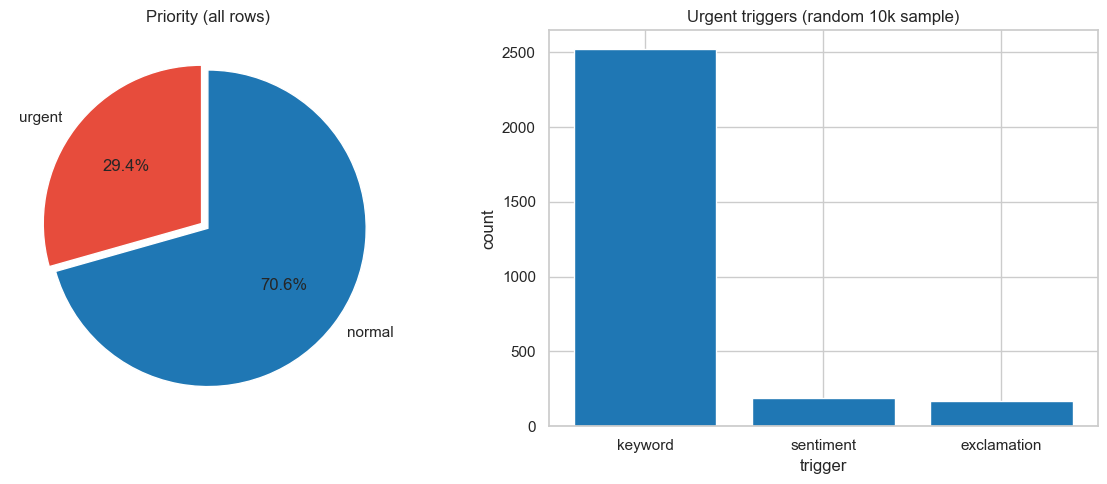

In [4]:
# Cell 4 — Sample trigger table + plots
print("\n[4/5] Sample trigger mix + plots…", flush=True)

sample_n = min(10_000, len(df))
sample_idx = df.sample(sample_n, random_state=RANDOM_STATE).index
sub = trigger.loc[sample_idx]
print(f"\n   Trigger counts in random sample of {sample_n:,}:", flush=True)
print(sub.value_counts().to_string(), flush=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    [urgent_n, normal_n],
    labels=["urgent", "normal"],
    autopct="%1.1f%%",
    colors=["#e74c3c", PLOT_COLOR],
    startangle=90,
    explode=(0.05, 0),
)
axes[0].set_title("Priority (all rows)")

plot_vc = sub.value_counts()
plot_vc = plot_vc[plot_vc.index.isin(["keyword", "exclamation", "sentiment"])]
if len(plot_vc):
    axes[1].bar(plot_vc.index.astype(str), plot_vc.values, color=PLOT_COLOR, edgecolor="white")
    axes[1].set_title("Urgent triggers (random 10k sample)")
    axes[1].set_xlabel("trigger")
    axes[1].set_ylabel("count")
else:
    axes[1].text(0.5, 0.5, "no urgent in sample", ha="center")

plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — Save artifacts + sanity checks
print("\n[5/5] Saving CSVs…", flush=True)

out_labeled = LABELED_DIR / "labeled_questions.csv"
out_sample = LABELED_DIR / "labeled_questions_sample.csv"
out_phase11 = CLEANED_DIR / "questions_labeled.csv"

df.to_csv(out_labeled, index=False)
df.head(1000).to_csv(out_sample, index=False)
df.to_csv(out_phase11, index=False)

def _mb(p: Path) -> float:
    return p.stat().st_size / (1024**2)

print(f"   ✅ {out_labeled.resolve()}  ({len(df):,} rows, {_mb(out_labeled):.1f} MB)", flush=True)
print(f"   ✅ {out_sample.resolve()}  (1000 rows)", flush=True)
print(f"   ✅ {out_phase11.resolve()}  (copy for Phase 11)", flush=True)

assert set(df["priority"].unique()) <= {"urgent", "normal"}
assert urgent_n + normal_n == len(df)

print("\n   First 10 rows (question_id, text snippet, priority):", flush=True)
show = df[["question_id", "question_text_for_ml", "priority"]].head(10).copy()
show["question_text_for_ml"] = show["question_text_for_ml"].astype(str).str.slice(0, 72)
print(show.to_string(index=False), flush=True)

print("\n" + "=" * 60, flush=True)
print("PHASE 10 COMPLETE", flush=True)
print("=" * 60, flush=True)


[5/5] Saving CSVs…
   ✅ C:\projects\decision-assistant\data\labeled\labeled_questions.csv  (1,537,843 rows, 227.3 MB)
   ✅ C:\projects\decision-assistant\data\labeled\labeled_questions_sample.csv  (1000 rows)
   ✅ C:\projects\decision-assistant\data\cleaned\questions_labeled.csv  (copy for Phase 11)

   First 10 rows (question_id, text snippet, priority):
 question_id                                                     question_text_for_ml priority
           8                                            is the worst customer service   urgent
           7                 the only way i can get a response is to tweet apparently   normal
           5                                                                   i did.   normal
           3   i have sent several private messages and no one is responding as usual   normal
           2                                        and how do you propose we do that   normal
          18 y’all lie about your “great” connection. 5 bars lte, still